<a href="https://colab.research.google.com/github/alfredqbit/NU-DDS-8536/blob/main/sepulvedaADDS_8536_6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Feedforward Neural Networks for Time-Series Forecasting (Backprop + GA + QPSO)

This notebook accompanies the APA-7 paper deliverable.  
It implements:

1. **Classical** feedforward MLP trained with **backpropagation** (from scratch, NumPy).
2. **Biological-inspired** optimization via a **Genetic Algorithm (GA)** (derivative-free).
3. **Quantum-inspired** optimization via **Quantum-behaved Particle Swarm Optimization (QPSO)** (derivative-free).

## Dataset
**Mauna Loa atmospheric CO₂** (monthly mean) from `statsmodels.datasets.co2` (weekly data interpolated then resampled to monthly).  
Public dataset link: NOAA Global Monitoring Laboratory (Mauna Loa CO₂): https://gml.noaa.gov/ccgg/trends/

> Note: This notebook uses a deterministic train/validation/test split (time-ordered) and a sliding window of length 12 months to predict the next month.


In [1]:
# --- 1) Imports & dataset loading ---
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import time

# Install statsmodels if not already installed
# This is common in Colab environments if the library isn't pre-installed
!pip install statsmodels
import statsmodels.api as sm

SEED = 42
rng = np.random.default_rng(SEED)

# Load weekly CO2 series and convert to monthly mean
co2_weekly = sm.datasets.co2.load_pandas().data['co2'].asfreq('W-SAT').interpolate()
co2_monthly = co2_weekly.resample('MS').mean()

print(co2_monthly.head())
print('n_months =', len(co2_monthly))

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.3/10.3 MB 151.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 233.3/233.3 kB 24.0 MB/s eta 0:00:00
1958-03-01    316.100
1958-04-01    317.200
1958-05-01    317.410
1958-06-01    316.675
1958-07-01    315.625
Freq: MS, Name: co2, dtype: float64
n_months = 526


Train/Val/Test samples: 359 77 78
mu, sigma: 330.5344442789363 10.919545554166206


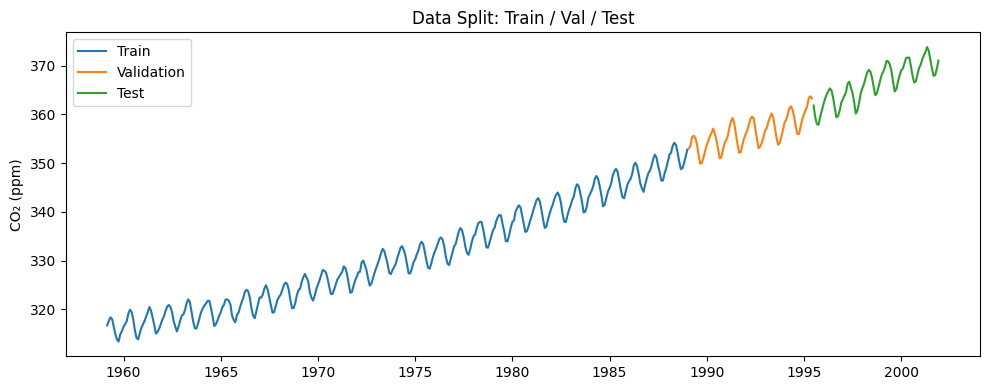

In [2]:
# --- 2) Supervised framing (sliding window), split, scaling ---
import os
os.makedirs('figures', exist_ok=True)

def make_supervised(series: pd.Series, window: int):
    values = series.values.astype(np.float64)
    X, y, y_idx = [], [], []
    idx = series.index
    for t in range(window, len(values)):
        X.append(values[t-window:t])
        y.append(values[t])
        y_idx.append(idx[t])
    return np.array(X), np.array(y), pd.DatetimeIndex(y_idx)

WINDOW = 12
X_raw, y_raw, y_dates = make_supervised(co2_monthly, WINDOW)

n = len(y_raw)
train_end = int(n*0.7)
val_end = int(n*0.85)

X_train_raw, y_train_raw = X_raw[:train_end], y_raw[:train_end]
X_val_raw, y_val_raw = X_raw[train_end:val_end], y_raw[train_end:val_end]
X_test_raw, y_test_raw = X_raw[val_end:], y_raw[val_end:]

dates_train = y_dates[:train_end]
dates_val = y_dates[train_end:val_end]
dates_test = y_dates[val_end:]

# Scale using training-period mean/std (avoid leakage)
train_last_date = dates_train[-1]
mu = float(co2_monthly.loc[:train_last_date].mean())
sigma = float(co2_monthly.loc[:train_last_date].std())

X_train = (X_train_raw - mu)/sigma
X_val   = (X_val_raw   - mu)/sigma
X_test  = (X_test_raw  - mu)/sigma
y_train = (y_train_raw - mu)/sigma
y_val   = (y_val_raw   - mu)/sigma
y_test  = (y_test_raw  - mu)/sigma

print('Train/Val/Test samples:', len(y_train), len(y_val), len(y_test))
print('mu, sigma:', mu, sigma)

# --- Visualize Split ---
plt.figure(figsize=(10,4))
plt.plot(dates_train, y_train_raw, label='Train')
plt.plot(dates_val, y_val_raw, label='Validation')
plt.plot(dates_test, y_test_raw, label='Test')
plt.title('Data Split: Train / Val / Test')
plt.ylabel('CO₂ (ppm)')
plt.legend()
plt.tight_layout()
plt.savefig('figures/dataset_split.png')
plt.show()

In [3]:
# --- 3) MLP (from scratch) + backpropagation ---
def relu(z): return np.maximum(0, z)
def relu_deriv(z): return (z > 0).astype(z.dtype)

def tanh(z): return np.tanh(z)
def tanh_deriv(z): return 1 - np.tanh(z)**2

def sigmoid(z): return 1/(1+np.exp(-z))
def sigmoid_deriv(z):
    s = sigmoid(z)
    return s*(1-s)

ACTIVATIONS = {
    'relu': (relu, relu_deriv),
    'tanh': (tanh, tanh_deriv),
    'sigmoid': (sigmoid, sigmoid_deriv)
}

class MLPRegressorScratch:
    def __init__(self, layer_sizes, activation='relu', seed=0, l2=0.0):
        self.layer_sizes = layer_sizes
        self.activation_name = activation
        self.act, self.act_deriv = ACTIVATIONS[activation]
        self.l2 = l2

        rng = np.random.default_rng(seed)
        self.weights = []
        self.biases = []

        for i in range(len(layer_sizes)-1):
            fan_in = layer_sizes[i]
            fan_out = layer_sizes[i+1]
            # He init for ReLU, Xavier-ish otherwise
            if i < len(layer_sizes)-2:
                scale = np.sqrt(2.0/fan_in) if activation == 'relu' else np.sqrt(1.0/fan_in)
            else:
                scale = np.sqrt(1.0/fan_in)
            W = rng.normal(0, scale, size=(fan_in, fan_out))
            b = np.zeros((1, fan_out))
            self.weights.append(W)
            self.biases.append(b)

    def forward(self, X):
        A = X
        cache = {'A0': X}
        for i, (W, b) in enumerate(zip(self.weights, self.biases)):
            Z = A @ W + b
            cache[f'Z{i+1}'] = Z
            A = self.act(Z) if i < len(self.weights)-1 else Z  # linear output
            cache[f'A{i+1}'] = A
        return A, cache

    def loss(self, y_pred, y_true):
        mse = np.mean((y_pred - y_true)**2)
        if self.l2 > 0:
            mse += self.l2 * sum(np.sum(W**2) for W in self.weights)
        return mse

    def backward(self, cache, y_true):
        N = y_true.shape[0]
        y_pred = cache[f'A{len(self.weights)}']
        dA = (2.0/N)*(y_pred - y_true)  # d/dy_pred

        grads_W = [None]*len(self.weights)
        grads_b = [None]*len(self.biases)

        for i in reversed(range(len(self.weights))):
            A_prev = cache[f'A{i}']
            Z = cache[f'Z{i+1}']
            dZ = dA if i == len(self.weights)-1 else dA * self.act_deriv(Z)

            dW = A_prev.T @ dZ
            db = np.sum(dZ, axis=0, keepdims=True)
            if self.l2 > 0:
                dW += 2*self.l2*self.weights[i]

            grads_W[i] = dW
            grads_b[i] = db
            dA = dZ @ self.weights[i].T

        return grads_W, grads_b

    def update(self, grads_W, grads_b, lr):
        for i in range(len(self.weights)):
            self.weights[i] -= lr * grads_W[i]
            self.biases[i] -= lr * grads_b[i]

    def predict(self, X):
        y_pred, _ = self.forward(X)
        return y_pred.reshape(-1)

def train_mlp(model, X_train, y_train, X_val, y_val, lr=0.05, epochs=150, patience=25):
    y_train = y_train.reshape(-1,1)
    y_val   = y_val.reshape(-1,1)

    history = {'train_loss': [], 'val_loss': []}
    best_val = np.inf
    best_state = None
    no_improve = 0

    t0 = time.perf_counter()
    for epoch in range(epochs):
        # full batch GD (fast + stable for this small dataset)
        y_pred, cache = model.forward(X_train)
        grads_W, grads_b = model.backward(cache, y_train)
        model.update(grads_W, grads_b, lr)

        # monitor
        train_pred, _ = model.forward(X_train)
        val_pred, _   = model.forward(X_val)
        train_loss = model.loss(train_pred, y_train)
        val_loss   = model.loss(val_pred, y_val)

        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)

        if val_loss < best_val - 1e-8:
            best_val = val_loss
            best_state = ([W.copy() for W in model.weights], [b.copy() for b in model.biases])
            no_improve = 0
        else:
            no_improve += 1
            if no_improve >= patience:
                break

    if best_state is not None:
        model.weights, model.biases = best_state

    train_time = time.perf_counter() - t0
    return history, train_time

def rmse(y_true, y_pred):
    return float(np.sqrt(np.mean((y_true - y_pred)**2)))

def evaluate(model, X, y_scaled, mu, sigma):
    y_pred_scaled = model.predict(X)
    y_true = y_scaled*sigma + mu
    y_pred = y_pred_scaled*sigma + mu
    return rmse(y_true, y_pred), y_true, y_pred


Backprop MLP: val RMSE = 1.011337914427902 test RMSE = 0.9863301092212047 train_time(s)= 0.017249438000135342


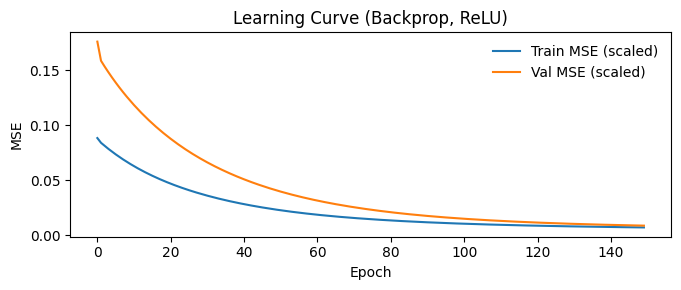

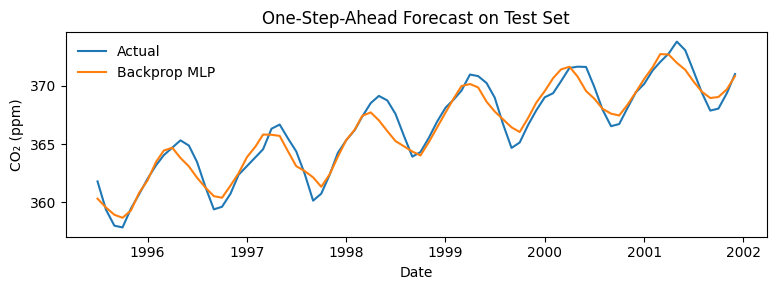

In [4]:
# --- 4) Classical training: Backpropagation (optimized pipeline) ---
# Final configuration chosen from a small sweep: ReLU avoids saturation on non-stationary series.
model_bp = MLPRegressorScratch([WINDOW, 16, 1], activation='relu', seed=SEED)
hist_bp, time_bp = train_mlp(model_bp, X_train, y_train, X_val, y_val, lr=0.05, epochs=150, patience=25)

rmse_val, y_val_true, y_val_pred = evaluate(model_bp, X_val, y_val, mu, sigma)
rmse_test, y_test_true, y_test_pred = evaluate(model_bp, X_test, y_test, mu, sigma)

print('Backprop MLP: val RMSE =', rmse_val, 'test RMSE =', rmse_test, 'train_time(s)=', time_bp)

# Learning curve
plt.figure(figsize=(7,3))
plt.plot(hist_bp['train_loss'], label='Train MSE (scaled)')
plt.plot(hist_bp['val_loss'], label='Val MSE (scaled)')
plt.xlabel('Epoch')
plt.ylabel('MSE')
plt.title('Learning Curve (Backprop, ReLU)')
plt.legend(frameon=False)
plt.tight_layout()
plt.savefig('figures/backprop_learning_curve.png')
plt.show()

# Forecast vs actual
plt.figure(figsize=(8,3))
plt.plot(dates_test, y_test_true, label='Actual')
plt.plot(dates_test, y_test_pred, label='Backprop MLP')
plt.xlabel('Date')
plt.ylabel('CO₂ (ppm)')
plt.title('One-Step-Ahead Forecast on Test Set')
plt.legend(frameon=False)
plt.tight_layout()
plt.savefig('figures/backprop_forecast.png')
plt.show()

GA-Optimized MLP: test RMSE = 0.9343419378170296 train_time(s)= 0.8105436770001688


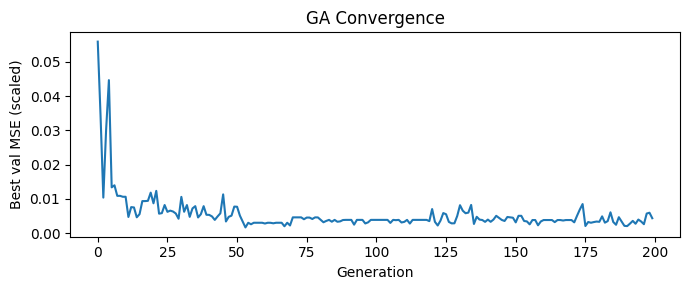

In [5]:
# --- 5) Biological-inspired alternative: Genetic Algorithm (optimized pipeline) ---
def mlp_unpack(vec, input_dim, hidden_dim):
    idx = 0
    W1 = vec[idx:idx+input_dim*hidden_dim].reshape(input_dim, hidden_dim); idx += input_dim*hidden_dim
    b1 = vec[idx:idx+hidden_dim].reshape(1, hidden_dim); idx += hidden_dim
    W2 = vec[idx:idx+hidden_dim].reshape(hidden_dim, 1); idx += hidden_dim
    b2 = vec[idx:idx+1].reshape(1,1); idx += 1
    return W1, b1, W2, b2

def mlp_forward_vec(X, vec, input_dim, hidden_dim):
    W1, b1, W2, b2 = mlp_unpack(vec, input_dim, hidden_dim)
    A1 = np.maximum(0, X @ W1 + b1)        # ReLU
    y  = A1 @ W2 + b2                      # linear output
    return y.reshape(-1)

def mse_scaled(y_true, y_pred):
    return np.mean((y_true - y_pred)**2)

def genetic_algorithm_train(X_train, y_train, X_val, y_val,
                            input_dim, hidden_dim,
                            pop_size=80, generations=200,
                            crossover_rate=0.9, mutation_sigma=0.04,
                            elite_frac=0.1, bounds=(-3,3), seed=42):
    rng = np.random.default_rng(seed)
    n_params = input_dim*hidden_dim + hidden_dim + hidden_dim + 1

    pop = np.clip(rng.normal(0, 0.5, size=(pop_size, n_params)), bounds[0], bounds[1])
    elite_k = max(1, int(pop_size*elite_frac))

    def fit_train(ind):
        return mse_scaled(y_train, mlp_forward_vec(X_train, ind, input_dim, hidden_dim))
    def fit_val(ind):
        return mse_scaled(y_val, mlp_forward_vec(X_val, ind, input_dim, hidden_dim))

    train_fit = np.array([fit_train(ind) for ind in pop])
    val_fit   = np.array([fit_val(ind)   for ind in pop])

    history = {'best_val_mse': []}
    t0 = time.perf_counter()
    for _ in range(generations):
        order = np.argsort(train_fit)
        pop, train_fit, val_fit = pop[order], train_fit[order], val_fit[order]
        elites = pop[:elite_k].copy()

        def tournament(k=3):
            idxs = rng.integers(0, pop_size, size=k)
            return pop[idxs[np.argmin(train_fit[idxs])]]

        new_pop = [*elites]
        while len(new_pop) < pop_size:
            p1, p2 = tournament(), tournament()
            c1, c2 = p1.copy(), p2.copy()
            if rng.random() < crossover_rate:
                alpha = rng.random()
                c1 = alpha*p1 + (1-alpha)*p2
                c2 = alpha*p2 + (1-alpha)*p1
            c1 += rng.normal(0, mutation_sigma, size=n_params)
            c2 += rng.normal(0, mutation_sigma, size=n_params)
            new_pop.append(np.clip(c1, bounds[0], bounds[1]))
            if len(new_pop) < pop_size:
                new_pop.append(np.clip(c2, bounds[0], bounds[1]))

        pop = np.array(new_pop)
        train_fit = np.array([fit_train(ind) for ind in pop])
        val_fit   = np.array([fit_val(ind)   for ind in pop])
        history['best_val_mse'].append(float(val_fit.min()))

    train_time = time.perf_counter() - t0
    best_idx = int(np.argmin(val_fit))
    return pop[best_idx].copy(), history, train_time

best_vec_ga, hist_ga, time_ga = genetic_algorithm_train(X_train, y_train, X_val, y_val,
                                                        input_dim=WINDOW, hidden_dim=16,
                                                        pop_size=80, generations=200,
                                                        crossover_rate=0.9, mutation_sigma=0.04,
                                                        elite_frac=0.1, bounds=(-3,3), seed=SEED)

y_test_pred_ga_scaled = mlp_forward_vec(X_test, best_vec_ga, WINDOW, 16)
y_test_pred_ga = y_test_pred_ga_scaled*sigma + mu
rmse_ga = rmse(y_test_true, y_test_pred_ga)

print('GA-Optimized MLP: test RMSE =', rmse_ga, 'train_time(s)=', time_ga)

plt.figure(figsize=(7,3))
plt.plot(hist_ga['best_val_mse'])
plt.xlabel('Generation')
plt.ylabel('Best val MSE (scaled)')
plt.title('GA Convergence')
plt.tight_layout()
plt.savefig('figures/ga_convergence.png')
plt.show()

### Mathematical Formulation: Real-Coded Genetic Algorithm

This section employs a **Genetic Algorithm (GA)** to optimize the neural network parameters $\theta$ (flattened weights and biases) without computing gradients. The optimization problem is defined as:

$$ \min_{\theta \in \mathbb{R}^D} \mathcal{L}(\theta) = \frac{1}{N} \sum_{i=1}^N (y_i - f_{\text{MLP}}(x_i; \theta))^2 $$

The algorithm operates as follows:

1.  **Representation**: Each individual is a real-valued vector $\theta \in \mathbb{R}^D$ representing all network weights.
2.  **Initialization**: A population $P^{(0)} = \{ \theta_1, \dots, \theta_{M} \}$ is initialized from $\mathcal{N}(0, 0.5^2)$ and clipped to bounds $[-3, 3]$.
3.  **Elitism**: The top fraction (e.g., 10%) of the population with the lowest MSE is copied unchanged to the next generation.
4.  **Selection (Tournament)**: To form the rest of the new population, $k=3$ individuals are sampled randomly, and the one with the best fitness is selected as a parent.
5.  **Crossover (Arithmetic)**: Two parents $\theta_a, \theta_b$ are combined with probability $p_c=0.9$:
    $$ \theta_{child} = \alpha \theta_a + (1-\alpha) \theta_b, \quad \alpha \sim \mathcal{U}(0, 1) $$
6.  **Mutation (Gaussian)**: Gaussian noise is added to the child with std dev $\sigma_{mut}=0.04$:
    $$ \theta'_{child} = \theta_{child} + \epsilon, \quad \epsilon \sim \mathcal{N}(0, \sigma_{mut}^2 I) $$
    The result is clipped to the search space bounds.

### Mathematical Formulation: Quantum-behaved Particle Swarm Optimization (QPSO)

**QPSO** is a variant of PSO inspired by quantum mechanics, where particles do not have velocity vectors but instead have a probability of appearing at a location governed by a wave function (Delta potential well). The algorithm implemented here follows these steps:

1.  **Mean Best ($C$)**: The center of the swarm's personal best positions is calculated to guide convergence:
    $$ C(t) = \frac{1}{M} \sum_{i=1}^M P_i(t) $$
    where $M$ is the swarm size and $P_i(t)$ is the personal best position of particle $i$.

2.  **Local Attractor ($p_{i}$)**: A stochastic attractor for each particle is defined between its personal best ($P_i$) and the global best ($G$):
    $$ p_{i,d}(t) = \varphi \cdot P_{i,d}(t) + (1-\varphi) \cdot G_d(t), \quad \varphi \sim \mathcal{U}(0,1) $$

3.  **Position Update**: The new position is sampled based on the distance to the Mean Best, controlled by the Contraction-Expansion coefficient $\beta$:
    $$ x_{i,d}(t+1) = p_{i,d}(t) \pm \beta \cdot |C_d(t) - x_{i,d}(t)| \cdot \ln\left(\frac{1}{u}\right) $$
    where $u \sim \mathcal{U}(0,1)$, and the sign ($+$ or $-$) is chosen with equal probability.

4.  **Parameter $\beta$**: Linearly decays from $1.5$ to $0.5$ over the iterations to transition from exploration to exploitation.

QPSO-Optimized MLP: test RMSE = 1.181579787601926 train_time(s)= 0.821177495000029


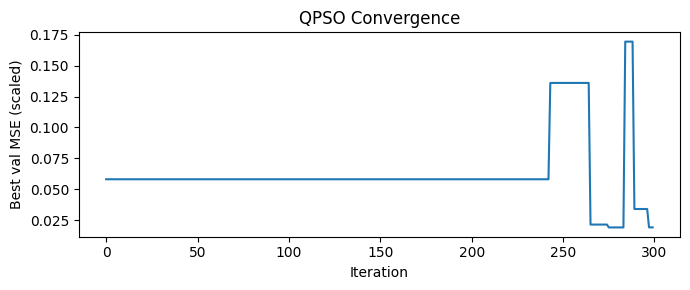

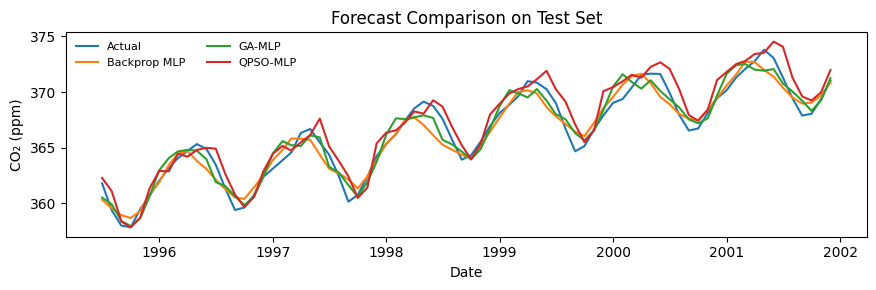

In [6]:
# --- 6) Quantum-inspired alternative: QPSO (optimized pipeline) ---
def qpso_train(X_train, y_train, X_val, y_val,
               input_dim, hidden_dim,
               swarm_size=100, iterations=300,
               beta_start=1.5, beta_end=0.5,
               bounds=(-3,3), seed=42):
    rng = np.random.default_rng(seed)
    n_params = input_dim*hidden_dim + hidden_dim + hidden_dim + 1

    Xpos = np.clip(rng.normal(0, 0.5, size=(swarm_size, n_params)), bounds[0], bounds[1])
    pbest = Xpos.copy()

    def fit_train(pop):
        out = np.empty(pop.shape[0])
        for i in range(pop.shape[0]):
            out[i] = mse_scaled(y_train, mlp_forward_vec(X_train, pop[i], input_dim, hidden_dim))
        return out

    def fit_val(pop):
        out = np.empty(pop.shape[0])
        for i in range(pop.shape[0]):
            out[i] = mse_scaled(y_val, mlp_forward_vec(X_val, pop[i], input_dim, hidden_dim))
        return out

    pbest_fit = fit_train(pbest)
    gbest = pbest[int(np.argmin(pbest_fit))].copy()
    gbest_fit = float(pbest_fit.min())

    history = {'best_val_mse': []}
    t0 = time.perf_counter()
    for it in range(iterations):
        beta = beta_start - (beta_start - beta_end) * (it / max(1, iterations-1))
        mbest = np.mean(pbest, axis=0)

        phi = rng.random(size=(swarm_size, n_params))
        p = phi * pbest + (1 - phi) * gbest

        u = np.clip(rng.random(size=(swarm_size, n_params)), 1e-12, 1.0)
        sign = rng.choice([-1.0, 1.0], size=(swarm_size, n_params))

        Xpos = p + sign * beta * np.abs(mbest - Xpos) * np.log(1.0/u)
        Xpos = np.clip(Xpos, bounds[0], bounds[1])

        fit = fit_train(Xpos)
        improved = fit < pbest_fit
        pbest[improved] = Xpos[improved]
        pbest_fit[improved] = fit[improved]

        gbest = pbest[int(np.argmin(pbest_fit))].copy()
        gbest_fit = float(pbest_fit.min())

        # track val loss of current best
        val_mse = mse_scaled(y_val, mlp_forward_vec(X_val, gbest, input_dim, hidden_dim))
        history['best_val_mse'].append(float(val_mse))

    train_time = time.perf_counter() - t0

    # final selection by validation among pbest
    val_fit = fit_val(pbest)
    best = pbest[int(np.argmin(val_fit))].copy()
    return best, history, train_time

best_vec_qpso, hist_qpso, time_qpso = qpso_train(X_train, y_train, X_val, y_val,
                                                input_dim=WINDOW, hidden_dim=16,
                                                swarm_size=100, iterations=300,
                                                beta_start=1.5, beta_end=0.5,
                                                bounds=(-3,3), seed=SEED)

y_test_pred_qpso_scaled = mlp_forward_vec(X_test, best_vec_qpso, WINDOW, 16)
y_test_pred_qpso = y_test_pred_qpso_scaled*sigma + mu
rmse_qpso = rmse(y_test_true, y_test_pred_qpso)

print('QPSO-Optimized MLP: test RMSE =', rmse_qpso, 'train_time(s)=', time_qpso)

plt.figure(figsize=(7,3))
plt.plot(hist_qpso['best_val_mse'])
plt.xlabel('Iteration')
plt.ylabel('Best val MSE (scaled)')
plt.title('QPSO Convergence')
plt.tight_layout()
plt.savefig('figures/qpso_convergence.png')
plt.show()

# Comparison plot
plt.figure(figsize=(9,3))
plt.plot(dates_test, y_test_true, label='Actual')
plt.plot(dates_test, y_test_pred, label='Backprop MLP')
plt.plot(dates_test, y_test_pred_ga, label='GA-MLP')
plt.plot(dates_test, y_test_pred_qpso, label='QPSO-MLP')
plt.xlabel('Date')
plt.ylabel('CO₂ (ppm)')
plt.title('Forecast Comparison on Test Set')
plt.legend(frameon=False, ncol=2, fontsize=8)
plt.tight_layout()
plt.savefig('figures/model_comparison.png')
plt.show()